In [21]:
# --- Check and install PuLP if not present ---
try:
    import pulp
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pulp"])
    import pulp


print(pulp.listSolvers(onlyAvailable=True))
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from pulp import LpProblem, LpVariable, LpBinary, LpMinimize, lpSum
import itertools


['PULP_CBC_CMD', 'HiGHS']


In [22]:

def make_nonzero_BIP(num_vars, num_constraints, seed=368):
    """
    Generate a minimization BIP with nonzero optimal solution.
    Ensures all-zero x is infeasible (b > 0) and feasible x with 1s exists.
    """
    rng = np.random.RandomState(seed + num_vars)

    c = rng.randint(1, 20, size=num_vars)  # positive costs
    A = rng.randint(0, 10, size=(num_constraints, num_vars))

    # Choose a feasible x with some 1s
    x_feasible = rng.randint(0, 2, size=num_vars)
    if x_feasible.sum() < 2:
        # ensure at least two 1's for stronger structure
        ones = rng.choice(num_vars, size=2, replace=False)
        x_feasible[ones] = 1

    # Set b so that x_feasible satisfies A x >= b
    b = A.dot(x_feasible)
    # Add positive RHS so x=0 is infeasible
    b = np.maximum(b - rng.randint(0, 3, size=b.shape), 1)

    return c, A, b, x_feasible

# --- Example test ---
def solve_bip_normally(c, A, b):
    N = len(c)
    model = pulp.LpProblem("BIP", pulp.LpMinimize)
    x = [pulp.LpVariable(f"x{i}", cat='Binary') for i in range(N)]

    model += pulp.lpSum(c[i] * x[i] for i in range(N))
    for j in range(len(A)):
        model += pulp.lpSum(A[j][i] * x[i] for i in range(N)) >= int(b[j])
    model += pulp.lpSum(x[i] for i in range(N)) >= 1  # coverage constraint

    model.solve(pulp.PULP_CBC_CMD(msg=False))
    x_val = [int(pulp.value(xi)) for xi in x]
    obj = pulp.value(model.objective)
    return pulp.LpStatus[model.status], x_val, obj




In [23]:
c, A, b, x_feas = make_nonzero_BIP(5,5)
status, x_opt, obj = solve_bip_normally(c, A, b)
print("c =", c)
print("b =", b)
print("A =\n", A)
print("known feasible =", x_feas)
print("Optimal:", x_opt, "Obj =", obj, "Status =", status)


c = [15 10 15  3 10]
b = [21  2 16 21  8]
A =
 [[5 9 4 4 9]
 [2 2 1 5 1]
 [8 4 4 6 9]
 [4 9 9 0 3]
 [4 1 7 5 2]]
known feasible = [0 1 1 0 1]
Optimal: [0, 1, 1, 0, 1] Obj = 35.0 Status = Optimal


In [26]:
# --- Generate valid vectors ---
def generate_valid_vectors(N):
    """Generate all 0/1 lists with the constraint: if vec[i] == 1, then vec[N+i] must be 1."""
    for vec in itertools.product([0, 1], repeat=2 * N):
        if all(not (vec[i] == 1 and vec[i + N] == 0) for i in range(N)):
            yield list(vec)  # convert tuple → mutable list



# --- Define your binary integer program ---
def solve_bip(vec, c, A, b):
    """
    Solve a binary integer program with bounds determined by vec.
    """
    N = len(c)
    model = LpProblem("BIP", LpMinimize)

    # Binary variables
    x = [LpVariable(f"x{i}", cat=LpBinary) for i in range(N)]

    # Apply lower/upper bounds from vec
    for i in range(N):
        x[i].lowBound = vec[i]
        x[i].upBound = vec[i + N]

    # Objective: minimize cᵀx
    model += lpSum(c[i] * x[i] for i in range(N))

    # Constraints: A x ≤ b
    for j in range(len(A)):
        model += lpSum(A[j][i] * x[i] for i in range(N)) >= b[j]

    # Solve
    output = model.solve(pulp.PULP_CBC_CMD(msg=False))

    return pulp.LpStatus[output],pulp.value(model.objective)


# --- Initialize global structures ---
Q = defaultdict(lambda: defaultdict(float))
v = defaultdict(float)
#Feas_Stat = ['O','I','F']
results = defaultdict(tuple)



In [32]:
# --- Q-learning Value Function ---
def value_function(vec):
    """
    Update Q-values and value function v for a given state vector vec.
    vec: list of length 2*N representing current branching state.
    """
    N = len(vec) // 2
    vecL = vec.copy()
    vecR = vec.copy()

    diff_sum = 0.0  # <-- track average diff for plotting
    for i in range(N):
        # Left action: fix variable i to 0
        vecL[i] = 0
        vecL[i + N] = 0
        # Right action: fix variable i to 1
        vecR[i] = 1
        vecR[i + N] = 1

        # Compute Q-values
        diffL = abs(results[tuple(vec)][0] - results[tuple(vecL)][0])
        diffR = abs(results[tuple(vec)][0] - results[tuple(vecR)][0])

        diff_sum += (diffL + diffR) / 2.0  # average over both branches

        Q[tuple(vec)][(i, 'L')] = diffL + v.get(tuple(vecL), 0.0)
        Q[tuple(vec)][(i, 'R')] = diffR + v.get(tuple(vecR), 0.0)

    # Update value function v
    #v_delta = v[tuple(vec)]
    v[tuple(vec)] = max(Q[tuple(vec)].values(), default=0.0)
    #delta = max(delta,abs(v_delta - v[tuple(vec)]))
    # Return mean of average differences for this vec
    #return v[tuple(vec)],diff_sum / N if N > 0 else 0.0
    return diff_sum / N if N > 0 else 0.0


Objective coefficients (c): [15 10 15  3 10]

Constraint matrix (A):
 [[5 9 4 4 9]
 [2 2 1 5 1]
 [8 4 4 6 9]
 [4 9 9 0 3]
 [4 1 7 5 2]]

RHS vector (b): [21  2 16 21  8]
Number of binary variables: 5


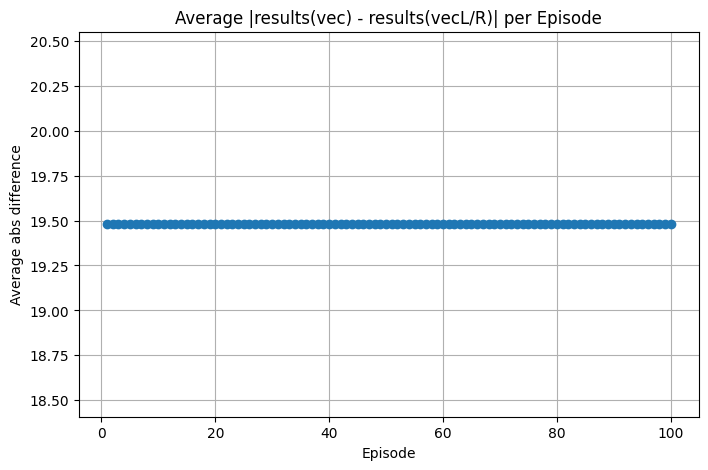


vec                           Value
------------------------------
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 21279.5
(0, 0, 0, 0, 0, 0, 0, 0, 0, 1) 21349.5
(0, 0, 0, 0, 0, 0, 0, 0, 1, 0) 21279.5
(0, 0, 0, 0, 0, 0, 0, 0, 1, 1) 21349.5
(0, 0, 0, 0, 0, 0, 0, 1, 0, 0) 21358.25
(0, 0, 0, 0, 0, 0, 0, 1, 0, 1) 21364.5
(0, 0, 0, 0, 0, 0, 0, 1, 1, 0) 21346.25
(0, 0, 0, 0, 0, 0, 0, 1, 1, 1) 21376.5
(0, 0, 0, 0, 0, 0, 1, 0, 0, 0) 21359.5
(0, 0, 0, 0, 0, 0, 1, 0, 0, 1) 21369.5
(0, 0, 0, 0, 0, 0, 1, 0, 1, 0) 21307.5
(0, 0, 0, 0, 0, 0, 1, 0, 1, 1) 21369.5
(0, 0, 0, 0, 0, 0, 1, 1, 0, 0) 21382.0
(0, 0, 0, 0, 0, 0, 1, 1, 0, 1) 21384.5
(0, 0, 0, 0, 0, 0, 1, 1, 1, 0) 21370.0
(0, 0, 0, 0, 0, 0, 1, 1, 1, 1) 21384.5
(0, 0, 0, 0, 0, 1, 0, 0, 0, 0) 21358.25
(0, 0, 0, 0, 0, 1, 0, 0, 0, 1) 21357.0
(0, 0, 0, 0, 0, 1, 0, 0, 1, 0) 21358.25
(0, 0, 0, 0, 0, 1, 0, 0, 1, 1) 21357.0
(0, 0, 0, 0, 0, 1, 0, 1, 0, 0) 21362.0
(0, 0, 0, 0, 0, 1, 0, 1, 0, 1) 21368.25
(0, 0, 0, 0, 0, 1, 0, 1, 1, 0) 21351.5
(0, 0, 0, 0, 0, 1, 0, 1, 1, 1)

In [34]:
import numpy as np
# --- Define a small test instance ---
c, A, b, x_feas = make_nonzero_BIP(5, 5)
N = len(c)
print("Objective coefficients (c):", c)
print("\nConstraint matrix (A):\n", A)
print("\nRHS vector (b):", b)
print("Number of binary variables:", N)



# Solving the optimization problem corresponding to each state
for vec in generate_valid_vectors(N):
    stat,obj_val = solve_bip(vec, c, A, b)
    if stat == 'Infeasible':
        results[tuple(vec)] = [obj_val , 'I']
    elif stat == 'Optimal':
        results[tuple(vec)] = [obj_val , 'O']
    else:
        results[tuple(vec)] = [obj_val , 'F']
# --- Main Learning Loop ---
avg_diffs_per_episode = []

for episode in range(100):
    vec_diffs = []

    for vec in generate_valid_vectors(N):
        #obj_val = solve_bip(vec, c, A, b)
        #results[tuple(vec)] = obj_val

        avg_diff_vec = value_function(vec)
        vec_diffs.append(avg_diff_vec)

    # Mean of all vec differences for this episode
    avg_diffs_per_episode.append(sum(vec_diffs) / len(vec_diffs))

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(range(1, 101), avg_diffs_per_episode, marker='o', linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Average abs difference")
plt.title("Average |results(vec) - results(vecL/R)| per Episode")
plt.grid(True)
plt.show()



# --- Print Final Value Function ---
print("\nvec".ljust(30), "Value")
print("-" * 30)
for vec, value in v.items():
    print(f"{str(vec).ljust(20)} {value}")


In [36]:
# --- Post-Learning Argmax Extraction ---
final_argmax = {}
for vec, actions in Q.items():
    if actions:
        best_action = max(actions, key=actions.get)
        final_argmax[vec] = best_action
    else:
        final_argmax[vec] = None

# --- Print Results ---
print("\nFinal Value Function and Best Actions:")
print("vec".ljust(30), "Value".ljust(10), "Best Action")
print("-" * 55)
for vec, best_action in final_argmax.items():
    best_val = Q[vec][best_action] if best_action else 0.0
    print(f"{str(vec).ljust(25)} {str(round(best_val, 4)).ljust(10)} {best_action}")


Final Value Function and Best Actions:
vec                            Value      Best Action
-------------------------------------------------------
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 21279.5    (4, 'R')
(0, 0, 0, 0, 0, 0, 0, 0, 0, 1) 21349.5    (4, 'L')
(0, 0, 0, 0, 0, 0, 0, 0, 1, 0) 21279.5    (3, 'L')
(0, 0, 0, 0, 0, 0, 0, 0, 1, 1) 21349.5    (3, 'L')
(0, 0, 0, 0, 0, 0, 0, 1, 0, 0) 21358.25   (2, 'L')
(0, 0, 0, 0, 0, 0, 0, 1, 0, 1) 21364.5    (2, 'L')
(0, 0, 0, 0, 0, 0, 0, 1, 1, 0) 21346.25   (2, 'L')
(0, 0, 0, 0, 0, 0, 0, 1, 1, 1) 21376.5    (2, 'L')
(0, 0, 0, 0, 0, 0, 1, 0, 0, 0) 21359.5    (1, 'L')
(0, 0, 0, 0, 0, 0, 1, 0, 0, 1) 21369.5    (1, 'L')
(0, 0, 0, 0, 0, 0, 1, 0, 1, 0) 21307.5    (1, 'L')
(0, 0, 0, 0, 0, 0, 1, 0, 1, 1) 21369.5    (1, 'L')
(0, 0, 0, 0, 0, 0, 1, 1, 0, 0) 21382.0    (1, 'L')
(0, 0, 0, 0, 0, 0, 1, 1, 0, 1) 21384.5    (1, 'L')
(0, 0, 0, 0, 0, 0, 1, 1, 1, 0) 21370.0    (1, 'L')
(0, 0, 0, 0, 0, 0, 1, 1, 1, 1) 21384.5    (1, 'L')
(0, 0, 0, 0, 0, 1, 0, 0, 0, 0) 213

In [52]:
def solve_bip_policy(vec):
    """
    Solve a binary integer program with bounds determined by policy.
    """
    status_str = 'Unrolling'
    action = final_argmax.get(tuple(vec))
    '''if action == None:
       return '''
    print(f"Current State :{str(vec).ljust(25)} {action}")
    index, direction = action
    #prev_vec = vec.copy()
     # Apply lower/upper bounds from action
    if direction == "L":
        vec[index] = 0
        vec[index + N] = 0
    elif direction == "R":
        vec[index] = 1
        vec[index + N] = 1
    merged = []
    if obj == results[tuple(vec)][0] and 'O' == results[tuple(vec)][1]:
            for i in range(N//2):
             if vec[i] == vec[i + N]:
              merged.append(vec[i])
             else:
              merged = []
              break
            if x_opt == merged:
             status_str = 'Optimal'
            print(f"\nValue at Current State = {results[tuple(vec)][0]}")

    elif results[tuple(vec)][1] == 'I':
         status_str = 'Infeasible'
    

    return status_str,vec    
     

In [53]:
import random
print("Objective coefficients (c):", c)
print("\nConstraint matrix (A):\n", A)
print("\nRHS vector (b):", b)
N = len(c)
#valid_vectors = list(generate_valid_vectors(N))
#vec = random.choice(valid_vectors)
vec = [0]*N + [1]*N
action = final_argmax.get(tuple(vec))
while True:
    # Solve your problem
    status_str,vec = solve_bip_policy(vec)

    if status_str in ['Optimal','Infeasible']:
        print(f"Stopping: {status_str}")
        break  # exit the loop
    else:
        print(f"Solver returned {status_str}, retrying...")
        # Optional: do something before retrying, e.g., change parameters

    


Objective coefficients (c): [15 10 15  3 10]

Constraint matrix (A):
 [[5 9 4 4 9]
 [2 2 1 5 1]
 [8 4 4 6 9]
 [4 9 9 0 3]
 [4 1 7 5 2]]

RHS vector (b): [21  2 16 21  8]
Current State :[0, 0, 0, 0, 0, 1, 1, 1, 1, 1] (0, 'L')

Value at Current State = 35.0
Solver returned Unrolling, retrying...
Current State :[0, 0, 0, 0, 0, 0, 1, 1, 1, 1] (1, 'L')
Stopping: Infeasible
